### Introduction: 

Jacksonville features dense coastal vegetation, inland waterways, estuarine marshes, asphalt highways, concrete infrastructure, and industrial port areas all captured within a single swath. This environmental complexity makes Jacksonville a perfect benchmark dataset for testing atmospheric correction, evaluating spectral quality, and demonstrating material classification techniques on Tanager data.

Here, the dataset (hyperspectral cube) is loaded, its wavelength rage is determined and no data  pixel values (if any) are checked and fill values ae determined

In [1]:
import h5py
import numpy as np
import matplotlib.pyplot as plt

#1. Load the data
file_path = "dataset/20250516_164837_16_4001_basic_sr_hdf5.h5"

with h5py.File(file_path, 'r') as f:
    sr_dataset = f['HDFEOS/SWATHS/HYP/Data Fields/surface_reflectance']
    cloud_mask = f['HDFEOS/SWATHS/HYP/Data Fields/beta_cloud_mask'][:]
    water_vapor = f['HDFEOS/SWATHS/HYP/Data Fields/column_water_vapour'][:]
    nodata = f['HDFEOS/SWATHS/HYP/Data Fields/nodata_pixels'][:]
    
    # Extract the attributes cleanly
    wavelengths = sr_dataset.attrs['wavelengths'][:]
    good_bands = sr_dataset.attrs['good_wavelengths'][:]
    
    # Handle string decoding safely for units
    wl_units = sr_dataset.attrs['wavelengths_units']
    if isinstance(wl_units, bytes):
        wl_units = wl_units.decode('utf-8')
    elif isinstance(wl_units, np.ndarray):
        wl_units = wl_units[0].decode('utf-8') if isinstance(wl_units[0], bytes) else wl_units[0]

    # FIX: Read fill value as a scalar directly
    fill_value = sr_dataset.attrs['_FillValue']
    if isinstance(fill_value, np.ndarray):
        fill_value = fill_value[0] # Only index if it actually loaded as an array
    
    # Load the actual data cube (bands, rows, cols)
    sr_cube = sr_dataset[:].astype(np.float32)



print(f"Spectral Range: {wavelengths.min():.2f} to {wavelengths.max():.2f} {wl_units}")
print(f"Number of 'Good' Bands: {int(good_bands.sum())} out of {len(good_bands)}")
print(f"Detected Fill Value: {fill_value}")

# Clean up fill/bad values using our fixed scalar
sr_cube[sr_cube == fill_value] = np.nan
sr_cube[sr_cube < 0] = np.nan

Spectral Range: 376.44 to 2499.00 nm
Number of 'Good' Bands: 368 out of 426
Detected Fill Value: -9999.0


To evaluate data quality across the scene, we construct a 2×2 multi-panel diagnostic dashboard that visualizes the spatial distribution of surface reflectance alongside key environmental and quality masks. 

Inspecting these spatial patterns together ensures we can systematically flag low-quality pixels and atmospheric distortions before running quantitative algorithms:

* **Top-Left (Surface Reflectance - Band 80):** Displays a single Near-Infrared (NIR) band rendered with the `viridis` colormap to highlight structural surface features, vegetation density, and land-water boundaries with high contrast.
* **Top-Right (Column Water Vapor):** Visualizes estimated atmospheric water vapor concentrations to evaluate regional atmospheric interference across the flight path.
* **Bottom-Left (Beta Cloud Mask):** Isolates opaque cloud cover and shadow artifacts to prevent contamination in downstream analytical steps.
* **Bottom-Right (NoData Pixel Mask):** Pinpoints explicit missing or corrupted sensor telemetry to ensure unmapped pixels are properly ignored.

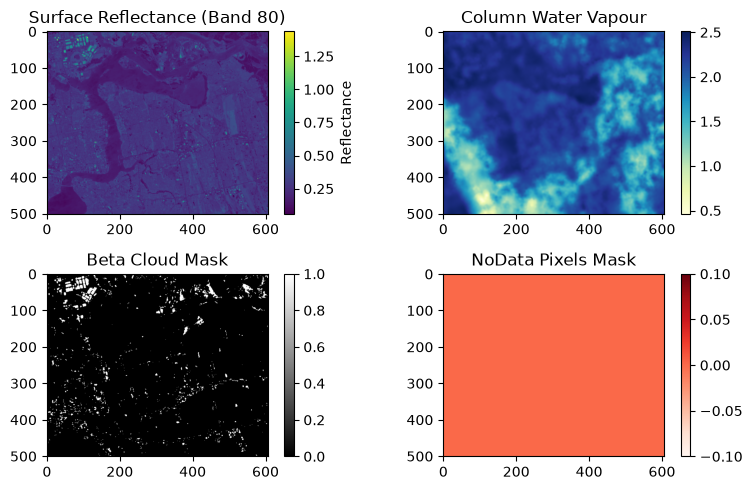

In [15]:
# 2. Select bands for a quick visualization
# If we don't know the exact wavelengths, let's pick 3 spread out early bands 
# to mimic an RGB composite, or just look at a single near-infrared band (e.g., band 80)
band_idx = 80
single_band = sr_cube[band_idx, :, :]

# 3. Plotting the EDA Dashboard
fig, axes = plt.subplots(2, 2, figsize=(8, 5))

# Top Left: Single Spectral Band
im1 = axes[0, 0].imshow(single_band, cmap='viridis')
axes[0, 0].set_title(f"Surface Reflectance (Band {band_idx})")
fig.colorbar(im1, ax=axes[0, 0], label='Reflectance')

# Top Right: Water Vapor
im2 = axes[0, 1].imshow(water_vapor, cmap='YlGnBu')
axes[0, 1].set_title("Column Water Vapour")
fig.colorbar(im2, ax=axes[0, 1])

# Bottom Left: Cloud Mask
im3 = axes[1, 0].imshow(cloud_mask, cmap='gray')
axes[1, 0].set_title("Beta Cloud Mask")
fig.colorbar(im3, ax=axes[1, 0])

# Bottom Right: NoData Pixels
im4 = axes[1, 1].imshow(nodata, cmap='Reds')
axes[1, 1].set_title("NoData Pixels Mask")
fig.colorbar(im4, ax=axes[1, 1])

plt.tight_layout()
plt.show()

### True Color Composite & Spectral Profile Extraction

This step constructs a realistic True Color (RGB) image from the hyperspectral cube and extracts the spectral signature of a representative central pixel. By automatically detecting the wavelength units—micrometers ($\mu m$) or nanometers ($nm$)—the code identifies the spectral bands nearest to standard Red (~650 nm), Green (~550 nm), and Blue (~470 nm) central wavelengths. A 2nd–98th percentile linear contrast stretch normalizes reflectance values to an displayable $[0, 1]$ range for visual inspection, while the adjacent plot isolates a single pixel's reflectance curve, highlighting valid measurements in teal to visually distinguish high-quality spectral bands from noisy atmospheric absorption regions.

Selected RGB Bands indices: Red=55, Green=35, Blue=19


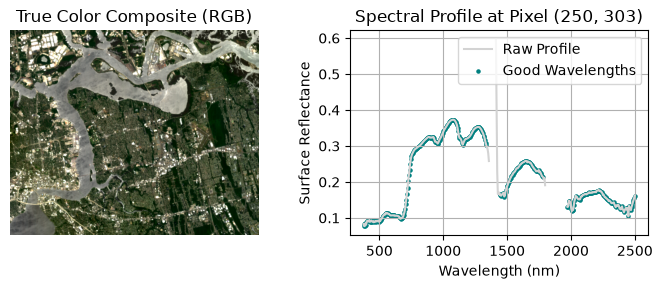

In [13]:
# --- Find Red, Green, Blue bands ---
is_micrometers = wavelengths.max() < 100
r_target = 0.65 if is_micrometers else 650
g_target = 0.55 if is_micrometers else 550
b_target = 0.47 if is_micrometers else 470

b_red = np.argmin(abs(wavelengths - r_target))
b_green = np.argmin(abs(wavelengths - g_target))
b_blue = np.argmin(abs(wavelengths - b_target))

print(f"Selected RGB Bands indices: Red={b_red}, Green={b_green}, Blue={b_blue}")

# Extract RGB channels and stack them
rgb = np.zeros((sr_cube.shape[1], sr_cube.shape[2], 3))
rgb[..., 0] = sr_cube[b_red, :, :]
rgb[..., 1] = sr_cube[b_green, :, :]
rgb[..., 2] = sr_cube[b_blue, :, :]

# Simple contrast stretch for visualization (percentile clip)
p2, p98 = np.nanpercentile(rgb, (2, 98))
rgb_clipped = np.clip((rgb - p2) / (p98 - p2), 0, 1)
rgb_clipped[np.isnan(rgb_clipped)] = 0 

# --- Plotting ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(7, 3))

# Left plot: True Color Image
ax1.imshow(rgb_clipped)
ax1.set_title("True Color Composite (RGB)")
ax1.axis('off')

# Right plot: Spectral Profile of a single pixel in the center
mid_row, mid_col = sr_cube.shape[1] // 2, sr_cube.shape[2] // 2
pixel_profile = sr_cube[:, mid_row, mid_col]

ax2.plot(wavelengths, pixel_profile, label='Raw Profile', color='lightgray')
ax2.scatter(wavelengths[good_bands == 1], pixel_profile[good_bands == 1], 
           s=5, color='teal', label='Good Wavelengths')

ax2.set_title(f"Spectral Profile at Pixel ({mid_row}, {mid_col})")
ax2.set_xlabel(f"Wavelength ({wl_units})")
ax2.set_ylabel("Surface Reflectance")
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

### Methane Spectral Absorption Band Proxy Mapping

This step generates a targeted absorption proxy map for atmospheric methane ($\text{CH}_4$) by exploiting its distinct spectral absorption features in the Short-Wave Infrared (SWIR-2) region. Methane exhibits strong, characteristic molecular absorption centered around $2350\text{ nm}$, whereas adjacent wavelengths near $2250\text{ nm}$ serve as a relatively unabsorbed baseline continuum. By computing the band ratio ($\text{Reflectance}_{2250\text{ nm}} / \text{Reflectance}_{2350\text{ nm}}$), higher ratio values effectively isolate areas where $2350\text{ nm}$ light is heavily attenuated by atmospheric methane plumes. Applying a 5th–95th percentile contrast stretch enhances subtle variations across the scene, allowing localized methane enhancements or point-source emissions over Jacksonville to stand out as high-intensity anomalies against the surrounding background.

Using Band 375 (2250.9nm) as Reference
Using Band 395 (2350.2nm) as Absorption Target


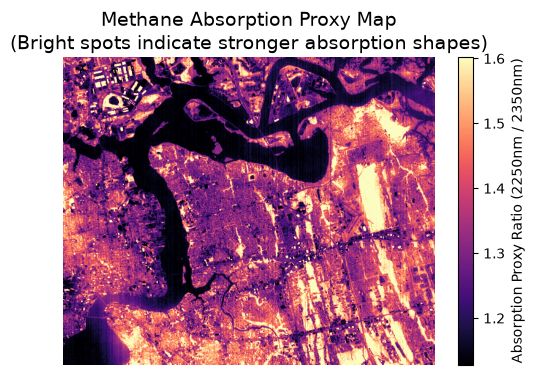

In [12]:
idx_ref = np.argmin(abs(wavelengths - 2250))
idx_abs = np.argmin(abs(wavelengths - 2350))

print(f"Using Band {idx_ref} ({wavelengths[idx_ref]:.1f}nm) as Reference")
print(f"Using Band {idx_abs} ({wavelengths[idx_abs]:.1f}nm) as Absorption Target")

# Extract the 2D planes
ref_plane = sr_cube[idx_ref, :, :]
abs_plane = sr_cube[idx_abs, :, :]

# Mask out bad/zero data to avoid division errors
mask = (ref_plane > 0) & (abs_plane > 0)
methane_proxy = np.zeros_like(ref_plane)
methane_proxy[mask] = ref_plane[mask] / abs_plane[mask]
methane_proxy[~mask] = np.nan

# --- Plot the Map ---
plt.figure(figsize=(6, 4))
# Use an aggressive percentile stretch to make subtle variations pop out
vmin, vmax = np.nanpercentile(methane_proxy, [5, 95])

plt.imshow(methane_proxy, cmap='magma', vmin=vmin, vmax=vmax)
plt.colorbar(label='Absorption Proxy Ratio (2250nm / 2350nm)')
plt.title("Methane Absorption Proxy Map\n(Bright spots indicate stronger absorption shapes)", fontsize=14)
plt.axis('off')
plt.show()

### Linear Regression Anomaly Detection for Methane Mapping

This step improves upon simple band ratioing by using a linear regression model to isolate true methane absorption anomalies from background land-cover variations (such as concrete, soil, or urban structures).

* **Baseline Regression (Scatter Plot):** Computes a linear fit ($y = mx + c$) between the reference band ($2250\text{ nm}$) and the absorption band ($2350\text{ nm}$) across all valid pixels in the scene. This establishes the expected natural relationship between the two spectral regions for typical surface materials.
* **Residual Calculation & Anomaly Map:** Predicts the expected $2350\text{ nm}$ reflectance across the scene and subtracts the actual observed reflectance ($\text{Residual} = \text{Expected} - \text{Observed}$). Pixels with large positive residuals indicate areas where light at $2350\text{ nm}$ is being absorbed significantly more than the background terrain predicts, effectively isolating atmospheric plume candidates from surface background features.

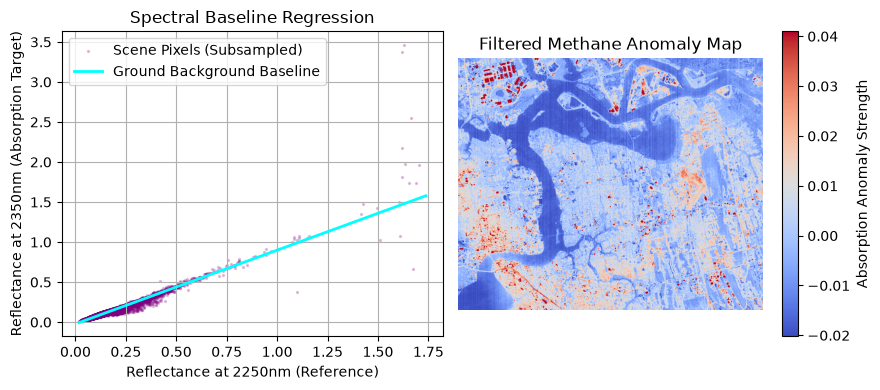

In [10]:
from scipy.stats import linregress

# 1. Extract our reference and absorption target bands
idx_ref = np.argmin(abs(wavelengths - 2250))
idx_abs = np.argmin(abs(wavelengths - 2350))

ref_plane = sr_cube[idx_ref, :, :]
abs_plane = sr_cube[idx_abs, :, :]

# Create a valid data mask (ignore no-data or zero pixels)
valid_mask = (ref_plane > 0.01) & (abs_plane > 0.01)

# 2. Flatten arrays to calculate global scene statistics
x_vals = ref_plane[valid_mask]
y_vals = abs_plane[valid_mask]

# Perform a linear regression to find the expected baseline of the ground
slope, intercept, r_value, p_value, std_err = linregress(x_vals, y_vals)

# 3. Predict the expected absorption plane based on the reference plane
expected_abs = slope * ref_plane + intercept

# 4. Calculate the residual (The deviation from the ground baseline)
# Negative residuals mean a pixel is absorbing MORE light than expected!
residual = expected_abs - abs_plane
residual[~valid_mask] = np.nan

# --- Plotting the Filtered Results ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 4))

# Left: Scatter plot showing the baseline fit
ax1.scatter(x_vals[::10], y_vals[::10], alpha=0.2, color='purple', s=2, label='Scene Pixels (Subsampled)')
x_line = np.linspace(x_vals.min(), x_vals.max(), 100)
ax1.plot(x_line, slope * x_line + intercept, color='cyan', linewidth=2, label='Ground Background Baseline')
ax1.set_title("Spectral Baseline Regression")
ax1.set_xlabel("Reflectance at 2250nm (Reference)")
ax1.set_ylabel("Reflectance at 2350nm (Absorption Target)")
ax1.legend()
ax1.grid(True)

# Right: The Residual Map (Filtered Methane View)
# We map the positive residuals (where absorption is unexpectedly high)
vmin, vmax = np.nanpercentile(residual, [1, 99])
im = ax2.imshow(residual, cmap='coolwarm', vmin=vmin, vmax=vmax)
fig.colorbar(im, ax=ax2, label='Absorption Anomaly Strength')
ax2.set_title("Filtered Methane Anomaly Map")
ax2.axis('off')

plt.tight_layout()
plt.show()


Comparing the **Atmospheric Water Vapor Column** product directly with the **Filtered Methane Anomaly Map** highlights how atmospheric moisture dynamics introduce scene-wide spectral interference:

* **Spatial Correlation of Broad Anomalies:** The diffuse, broad-scale regional variations visible across the central and right portions of the methane anomaly map closely mirror the spatial distribution of the atmospheric water vapor column. Areas with shifting moisture levels coincide with subtle background shifts in the anomaly map, confirming that uncorrected atmospheric water vapor acts as a scene-wide confounding variable.
* **Overlapping Spectral Absorption Wings:** Because water vapor absorption features spill into the SWIR-2 region ($2250\text{--}2350\text{ nm}$), variations in column water vapor alter the expected baseline ratio between the target and reference channels, generating widespread, low-intensity background noise (shown in light red/orange hues).
* **Decoupling Plumes from Moisture Dynamics:** Unlike broad atmospheric water vapor gradients—which cover wide areas with continuous, low-frequency variations—true target gas emissions display concentrated, high-contrast plume structures near ground point sources. Accounting for column water vapor values allows us to distinguish atmospheric moisture artifacts from localized industrial or natural anomalies.